# Lab 3: Multi-Class Classification of Data Practices

![Data Classification](https://www.xcitium.com/blog/wp-content/uploads/2026/02/data-classification-best-practices.png)

Figure: Data classification framework applied to privacy policy analysis

## Overview

In this lab, we move from binary classification to multi-class classification.

Previously, we only determined whether a sentence describes a data practice. In this lab, we identify the specific type of data practice being performed.

The categories used are:

- Collect  
- Share  
- Store  
- Use  

This approach provides a more detailed understanding of how applications handle user data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Learning Objectives

By the end of this lab, students will be able to:

- Understand multi-class classification
- Create multiple labels for different data practices
- Train machine learning models for multi-class prediction
- Evaluate performance using classification metrics
- Compare binary vs multi-class classification

## What is Multi-Class Classification?

In previous labs, we used **binary classification**:

- 0 → Not Data Practice  
- 1 → Data Practice  

In this lab, we use **multi-class classification**:

- 0 → Not Data Practice  
- 1 → Collect  
- 2 → Share  
- 3 → Store  
- 4 → Use  

👉 The model must now predict the **type of action**, not just whether it exists.

### Example

Sentence:
"We collect your location data to improve our services."  
→ Label: Collect (1)

Sentence:
"We may share your information with third parties."  
→ Label: Share (2)

Sentence:
"We store your data for security purposes."  
→ Label: Store (3)

### What is TF-IDF?

TF-IDF converts text into numerical features by measuring how important a word is in a sentence relative to all sentences.

This allows machine learning models to process text data.

## Step 1: Setup

In this step, we install and import the required libraries for data processing and machine learning.

In [ ]:
# Install required libraries
!pip -q install pandas scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import re

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

## Step 2: Load Dataset

In this step, we load the sentence-level dataset created in the previous lab.

This dataset contains cleaned text and labels that will be used for multi-class classification.

In [ ]:
sent_df = pd.read_csv("sentences_dataset.csv")
sent_df.head()

,sentence_text,clean_text,is_data_practice
0,Privacy Policy Skip to main content Home Help ...,privacy policy skip to main content home help ...,1
1,We refer to these collectively as the “Service...,we refer to these collectively as the services...,1
2,If you are looking for information about how a...,if you are looking for information about how a...,0
3,If you use the CVS App Personal Health Record ...,if you use the cvs app personal health record ...,0
4,"By using our Services, you agree to the collec...",by using our services you agree to the collect...,0


## Step 3: Create Multi-Class Labels

In this step, we convert binary labels into multi-class labels.

Instead of only identifying whether a sentence is a data practice, we classify the type of action.

The classes are defined as follows:

0 → Not Data Practice  
1 → Collect  
2 → Share  
3 → Store  
4 → Use  

We use keyword-based rules to assign labels based on the presence of action-related words.

Note that these labels are automatically generated, so some noise and misclassification may occur.

In [ ]:
# Define classification function
def classify_action(text):
    text = str(text).lower()

    collect_keywords = [
        "collect", "gather", "obtain", "receive", "request",
        "acquire", "ask", "provide", "enter", "submit",
        "input", "capture"
    ]

    share_keywords = [
        "share", "disclose", "transfer", "send",
        "reveal", "communicate", "sell", "distribute",
        "exchange"
    ]

    store_keywords = [
        "store", "retain", "save", "keep",
        "cache", "archive", "record", "log",
        "maintain"
    ]

    use_keywords = [
        "use", "process", "analyze", "utilize",
        "access", "monitor", "evaluate", "improve",
        "operate"
    ]

    if any(word in text for word in collect_keywords):
        return 1
    elif any(word in text for word in share_keywords):
        return 2
    elif any(word in text for word in store_keywords):
        return 3
    elif any(word in text for word in use_keywords):
        return 4
    else:
        return 0


# Apply labeling
sent_df["multi_label"] = sent_df["clean_text"].apply(classify_action)

# Check distribution
print(sent_df["multi_label"].value_counts())

# Preview dataset
sent_df.head()

multi_label
1    1584
0    1386
4     697
3     388
2     315
Name: count, dtype: int64


,sentence_text,clean_text,is_data_practice,multi_label
0,Privacy Policy Skip to main content Home Help ...,privacy policy skip to main content home help ...,1,1
1,We refer to these collectively as the “Service...,we refer to these collectively as the services...,1,1
2,If you are looking for information about how a...,if you are looking for information about how a...,0,1
3,If you use the CVS App Personal Health Record ...,if you use the cvs app personal health record ...,0,3
4,"By using our Services, you agree to the collec...",by using our services you agree to the collect...,0,1


## Step 4: Train-Test Split and Feature Extraction

In this step, we split the dataset into training and testing sets.

We then convert text into numerical features using TF-IDF so that machine learning models can process the data.

TF-IDF helps represent the importance of words in each sentence relative to the dataset.

In [ ]:
# Define features and labels
X = sent_df["clean_text"]
y = sent_df["multi_label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# Check shapes
print("Training shape:", X_train_vec.shape)
print("Testing shape:", X_test_vec.shape)

Training shape: (3496, 13722)
Testing shape: (874, 13722)


## Step 5: Train Multi-Class Model

In this step, we train a Logistic Regression model for multi-class classification.

Logistic Regression is a strong baseline model for text classification. It works well with TF-IDF features and is efficient for multi-class problems.

In [ ]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=2000)

model.fit(X_train_vec, y_train)

# Make predictions
y_pred = model.predict(X_test_vec)

## Step 6: Evaluate Model

In this step, we evaluate the performance of the model using classification metrics.

We use a classification report to measure precision, recall, and F1-score for each class. We also use a confusion matrix to understand prediction errors.

In [ ]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.92      0.81       277
           1       0.74      0.92      0.82       317
           2       1.00      0.29      0.44        63
           3       0.89      0.31      0.46        78
           4       0.86      0.53      0.66       139

    accuracy                           0.76       874
   macro avg       0.84      0.59      0.64       874
weighted avg       0.79      0.76      0.73       874

Confusion Matrix:

[[254  20   0   0   3]
 [ 20 292   0   3   2]
 [ 18  26  18   0   1]
 [ 21  27   0  24   6]
 [ 37  28   0   0  74]]


## Step 7: Support Vector Machine Model

In this step, we train a Support Vector Machine (SVM) model for multi-class classification.

SVM is effective for text classification because it handles high-dimensional data well and can separate classes with complex boundaries.

We compare its performance with Logistic Regression.

In [ ]:
from sklearn.svm import LinearSVC

# Train SVM model
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_vec)

# Evaluate model
print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.93      0.87       277
           1       0.86      0.92      0.89       317
           2       0.89      0.67      0.76        63
           3       0.80      0.55      0.65        78
           4       0.78      0.67      0.72       139

    accuracy                           0.83       874
   macro avg       0.83      0.75      0.78       874
weighted avg       0.83      0.83      0.83       874



## Step 8: Error Analysis

In this step, we analyze the errors made by the model.

We compare the true labels with predicted labels to identify where the model makes mistakes.

This helps us understand the limitations of the model and common patterns in misclassification.

In [ ]:
# Create dataframe of predictions
errors = pd.DataFrame({
    "text": X_test,
    "true_label": y_test,
    "predicted_label": y_pred
})

# Show incorrect predictions
errors[errors["true_label"] != errors["predicted_label"]].head(10)

,text,true_label,predicted_label
707,get a free proposal info letsnurture com skip ...,4,0
1593,a tracking pixel is a miniature graphic embedd...,3,0
2648,climax technology services we will manage and ...,1,3
3897,g audio electronic visual thermal olfactory or...,3,1
2503,our good faith estimate of the value of your p...,4,0
61,to conduct analysis and develop and or improve...,4,1
3408,application privacy statement lax skip to main...,1,0
1545,i recipient recipient is a natural or legal pe...,2,0
3939,f right to opt out of sales the right to direc...,2,1
4255,retention period for personal data we retain y...,3,1


## Error Analysis Observations

From the misclassified examples, several patterns can be observed:

1. Some sentences labeled as "Use" are predicted as "Not Data Practice".  
   This happens when the action is implied rather than explicitly stated.

2. Several "Store" sentences are misclassified as "Not Data Practice" or "Collect".  
   This suggests that storage-related terms are less distinct or less frequent in the dataset.

3. "Share" sentences are sometimes predicted as "Not Data Practice" or "Collect".  
   This may be due to overlapping language used in privacy policies.

4. Some sentences contain multiple actions, but the model predicts only one class.  
   For example, a sentence may describe both collecting and storing data.

5. Complex or vague sentences reduce model accuracy.  
   Privacy policies often use indirect language, making classification more difficult.

## Key Insight

The model performs well on clear and direct statements but struggles with:

- Implicit actions  
- Overlapping meanings between categories  
- Less frequent classes such as Share and Store  

This highlights the limitations of rule-based labeling and traditional machine learning models.

## Step 9: Confusion Matrix Visualization

In this step, we visualize the confusion matrix to better understand how the model makes predictions.

The confusion matrix shows how often each class is correctly or incorrectly predicted.

This helps identify which classes are most frequently confused with each other.

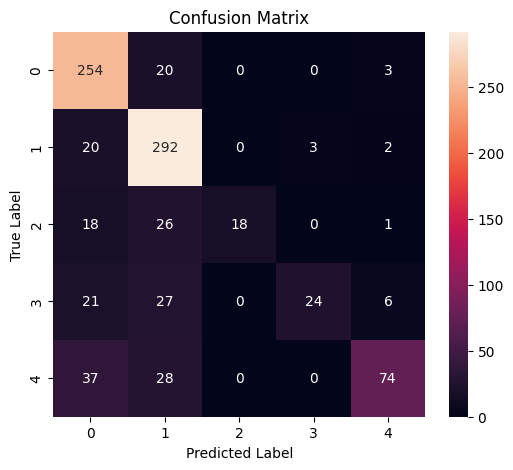

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

##  Comparison with Lab 2

Lab 2 used binary classification:
- Data Practice vs Not Data Practice

Lab 3 uses multi-class classification:
- Type of data practice (collect, share, store, use)

---

### Key Differences:

- Binary classification is easier and achieves higher recall
- Multi-class classification is more informative but more difficult
- The model must distinguish between subtle differences in language

---

### Insight

Multi-class classification provides deeper insights into privacy policies but requires more advanced modeling.

## Conclusion

In this lab, we extended binary classification to multi-class classification of data practices.

We classified sentences into five categories: Not Data Practice, Collect, Share, Store, and Use.

The results show that:

- The model performs well on dominant classes such as Not Data Practice and Collect  
- Performance is lower for minority classes such as Share and Store  
- The model struggles with overlapping and ambiguous language  

Overall, multi-class classification provides more detailed insights compared to binary classification, but it is also more challenging.

This lab demonstrates that model performance depends on data quality, class distribution, and the complexity of language in privacy policies.